In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats

In [2]:
df = pd.read_csv("/Users/furkandurmaz/Library/Mobile Documents/com~apple~CloudDocs/KocUniversity/Projects/MarketinABTest/marketing_AB.csv")
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
# Grup büyüklükleri
print(df['test group'].value_counts())

# Temiz veri
df_clean = df[df['total ads'] <= 500].copy()
print(f"Kalan satır: {len(df_clean)}")

test group
ad     564577
psa     23524
Name: count, dtype: int64
Kalan satır: 587516


In [4]:
df_clean.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [6]:
from scipy import stats
import numpy as np

# Grupları ayır
ad_group = df[df['test group'] == 'ad']['converted']
psa_group = df[df['test group'] == 'psa']['converted']

# Conversion sayıları
ad_conv = ad_group.sum()
ad_total = len(ad_group)
psa_conv = psa_group.sum()
psa_total = len(psa_group)

# Z-test
from statsmodels.stats.proportion import proportions_ztest
count = np.array([ad_conv, psa_conv])
nobs = np.array([ad_total, psa_total])
z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.2e}")

Z-statistic: 7.3701
P-value: 1.71e-13


In [7]:

p1 = ad_conv / ad_total
p2 = psa_conv / psa_total

# Cohen's h
h = 2 * np.arcsin(np.sqrt(p1)) - 2 * np.arcsin(np.sqrt(p2))
print(f"Cohen's h: {h:.4f}")
print(f"Ad conversion rate: {p1:.4f}")
print(f"PSA conversion rate: {p2:.4f}")

Cohen's h: 0.0530
Ad conversion rate: 0.0255
PSA conversion rate: 0.0179


In [8]:
from statsmodels.stats.power import NormalIndPower

effect_size = 0.053
alpha = 0.05
power = 0.80

analysis = NormalIndPower()
n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)
print(f"Gereken minimum örneklem (her grup): {n:.0f}")

Gereken minimum örneklem (her grup): 5588


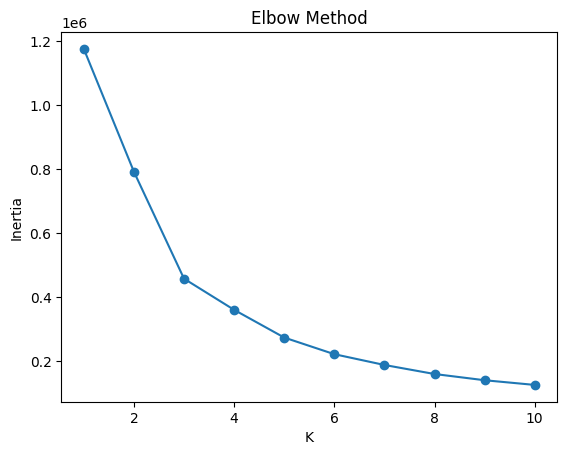

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Temiz veri üzerinde çalış
features = df_clean[['total ads', 'most ads hour']].copy()

# Scale et
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Elbow method — kaç cluster?
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [10]:
# K=4 ile fit et
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = km.fit_predict(X_scaled)

# Her cluster'ın profili
profile = df_clean.groupby('cluster').agg(
    kullanici_sayisi=('user id', 'count'),
    ort_reklam=('total ads', 'mean'),
    ort_saat=('most ads hour', 'mean'),
    conversion_rate=('converted', 'mean')
).round(3)

print(profile)

         kullanici_sayisi  ort_reklam  ort_saat  conversion_rate
cluster                                                         
0                  272325      14.769    10.608            0.011
1                  257672      14.698    18.550            0.014
2                    7516     256.582    14.032            0.154
3                   50003      89.271    14.545            0.141


In [11]:
segment_ab = df_clean.groupby(['cluster', 'test group'])['converted'].mean().unstack()
print(segment_ab)

test group        ad       psa
cluster                       
0           0.010736  0.007119
1           0.014264  0.012909
2           0.154564  0.140762
3           0.143525  0.078065
